In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image

In [12]:
# _path = r'C:\Users\hp\Desktop\blister\pseudo_color_prediction\27.png'
_path = r'C:\Users\hp\Desktop\low_angle\umages2\1.bmp'

img_PIL = Image.open(_path)
img = np.array(img_PIL)
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

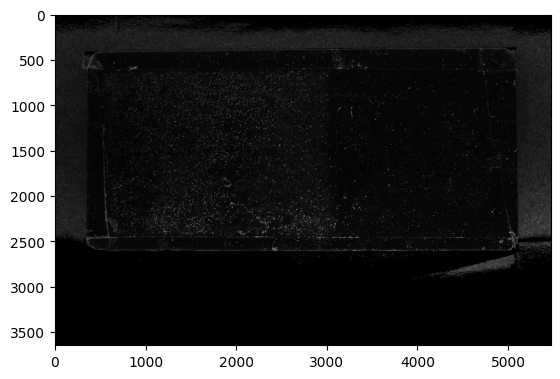

In [18]:
th = 100
# retval, img_binary = cv2.threshold(img, th, 255, cv2.THRESH_BINARY_INV) #
# img_binary = cv2.Canny(img,50,100)
img_binary = cv2.Laplacian(img,-1)

img_binary = cv2.morphologyEx(img_binary,cv2.MORPH_DILATE, cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)) )
plt.imshow(img_binary, cmap='gray')
plt.show()

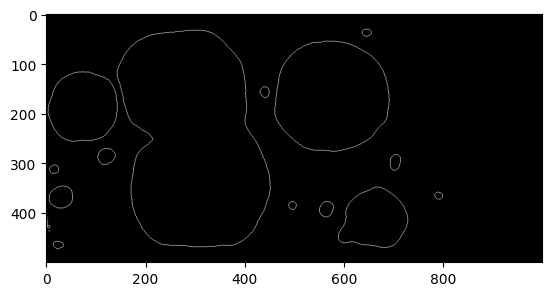

In [4]:
img2 = cv2.Laplacian(img_binary, -1)
plt.imshow(img2, cmap='gray')
plt.show()

In [5]:
#找轮廓并发现最大轮廓
index_tune = 0
contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# contours, hierarchy	= cv2.findContours(img2, cv2.RETR_FLOODFILL, cv2.CHAIN_APPROX_NONE)

# contours = np.array(contours, dtype=object) #轮廓的长度不一样，无法表示为一个固定大小的numpy数组
contours_size = np.array([cv2.contourArea(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[index_tune] #取一个轮廓，按t增加索引

In [6]:
def drawRotateRectCV( img, rotateRect, color = (0,122,255), thickness= 5):
    points = cv2.boxPoints(rotateRect)
    for i in range(0,4):
        cv2.line(img, [int(points[i][0]), int(points[i][1])], [int(points[(i+1)%4][0]), int(points[(i+1)%4][1])], 
                    color, thickness=thickness)

In [7]:
#多边形拟合
# _src_path = r'C:\Users\hp\Desktop\tc_data\2\rs\blister\27.jpg'
_src_path = r'C:\Users\hp\Desktop\tc_data\2\rs\rust\23.jpg'

src_img = cv2.imread(_src_path)
contour = contours[sort_index[0]]
t1 = time.time()
poly = cv2.approxPolyDP(contour, 1, True) #多边形拟合
print(time.time()-t1)
print(poly.shape)
cv2.drawContours(src_img, [poly], 0, (255,0,255), thickness=3) #画原轮廓

rr = cv2.minAreaRect(poly)
print(rr)
drawRotateRectCV(src_img, rr, color=(0,50, 200), thickness=2)
# plt.imshow(src_img)
# plt.show()

t1 = time.time()
_a = cv2.contourArea(poly)
print(time.time()-t1)
print(_a, np.math.sqrt(_a))
_lw_index=[0, 1]
if rr[1][0]<rr[1][1]:
    _lw_index = [1, 0]
max_ratio = _a/(img_binary.shape[0]*img_binary.shape[1])
_max_str = [str(int(_a)), str(int(rr[1][_lw_index[0]])), str(int(rr[1][_lw_index[1]])), 
            '{:.9f}'.format(max_ratio)]
print(_max_str)

0.0004930496215820312
(70, 1, 2)
((299.7082214355469, 253.26963806152344), (440.3746643066406, 281.7626647949219), 83.2901611328125)
0.0
101818.0 319.0893291854179
['101818', '440', '281', '0.203636000']


0.0
(4, 1, 2)
((1.250000238418579, 409.2500305175781), (3.1622774600982666, 1.5811387300491333), 71.56504821777344)
0.0
0.0 0.0
['0', '3', '1']


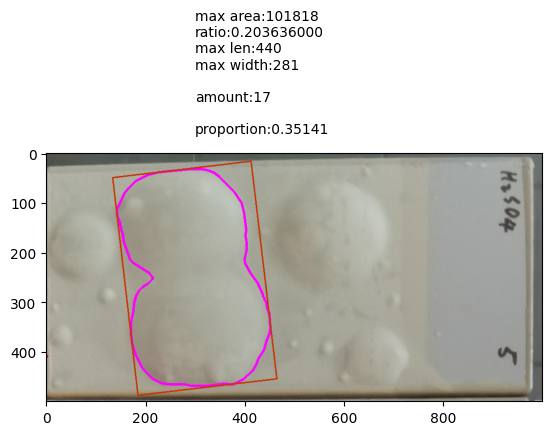

In [8]:
contour = contours[sort_index[-1]]
t1 = time.time()
poly = cv2.approxPolyDP(contour, 1, True) #多边形拟合
print(time.time()-t1)
print(poly.shape)
cv2.drawContours(src_img, [poly], 0, (255,0,255), thickness=3) #画原轮廓

rr = cv2.minAreaRect(poly)
print(rr)
drawRotateRectCV(src_img, rr, color=(0,25, 200), thickness=2)


t1 = time.time()
_a = cv2.contourArea(poly)
print(time.time()-t1)
print(_a, np.math.sqrt(_a))
_lw_index=[0, 1]
if rr[1][0]<rr[1][1]:
    _lw_index = [1, 0]
_min_str = [str(int(_a)), str(int(rr[1][_lw_index[0]])), str(int(rr[1][_lw_index[1]]))]
print(_min_str)

plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
# +'min area:'+_min_str[0]+'\n'+'min len:'+_min_str[1]+'\n'+'min width:'+_min_str[2]+'\n\n'
plt.text(300, -40, 
         'max area:'+_max_str[0]+'\n' +'ratio:'+_max_str[3]+'\n' +'max len:'+_max_str[1]+'\n'+'max width:'+_max_str[2]+'\n\n'
         +'amount:'+str(len(sort_index))+'\n\n'
         +'proportion:'+str(np.sum(contours_size)/(1000.*500.) )[:7] )
plt.show()

In [ ]:
#特定轮廓多边形拟合
contour = contours[sort_index[0]]
print(contour.shape)
src_img = cv2.imread(r'C:\Users\hp\Desktop\tc_data\2\rs\blister\26.jpg')
t1 = time.time()
poly = cv2.approxPolyDP(contour, 2, True) #多边形拟合
print(time.time()-t1)
print(poly.shape)
cv2.drawContours(src_img, [poly], 0, (255,0,255), thickness=3) #画原轮廓
plt.imshow(src_img)
plt.show()